In [1]:
import open3d as o3d
import numpy as np 
import cv2 
from skimage import measure
import matplotlib.pyplot as plt 

from src.segment_enhanced_model import SegmentEnhancedModel
from src.volume_estimation import VolumeEstimator

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


def generate_3d_volume_with_color(original_image, depth_layers=10):
    original_image_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)
    normalized = gray.astype(float) / 255.0
    volume = np.zeros((gray.shape[0], gray.shape[1], depth_layers), dtype=float)
    for z in range(depth_layers):
        depth_factor = 1.0 - (z / depth_layers)
        volume[:, :, z] = normalized * depth_factor
    return volume, original_image_rgb, original_image

def create_mesh_with_color(volume, original_image_rgb, depth_layers=10):
    verts, faces, _, _ = measure.marching_cubes(volume, level=0.1)
    mesh = o3d.geometry.TriangleMesh()
    mesh_vertices = np.column_stack([verts[:, 1], verts[:, 0], verts[:, 2]])
    mesh.vertices = o3d.utility.Vector3dVector(mesh_vertices)
    mesh.triangles = o3d.utility.Vector3iVector(faces)
    vertex_colors = []
    height, width = original_image_rgb.shape[:2]
    for vertex in mesh_vertices:
        x = int(np.clip(vertex[0], 0, width - 1))
        y = int(np.clip(vertex[1], 0, height - 1))
        color = original_image_rgb[y, x] / 255.0
        vertex_colors.append(color)
    mesh.vertex_colors = o3d.utility.Vector3dVector(vertex_colors)
    mesh.compute_vertex_normals()
    mesh = mesh.filter_smooth_laplacian(number_of_iterations=3)
    return mesh

In [2]:
input_image_path = "./src/images/x003.jpeg"

In [3]:
original_image = cv2.imread(input_image_path)
image_test = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
image_test_rgb = cv2.resize(image_test, (512, 512))

In [4]:
enhanced_model = SegmentEnhancedModel(sam_model_type="vit_b")

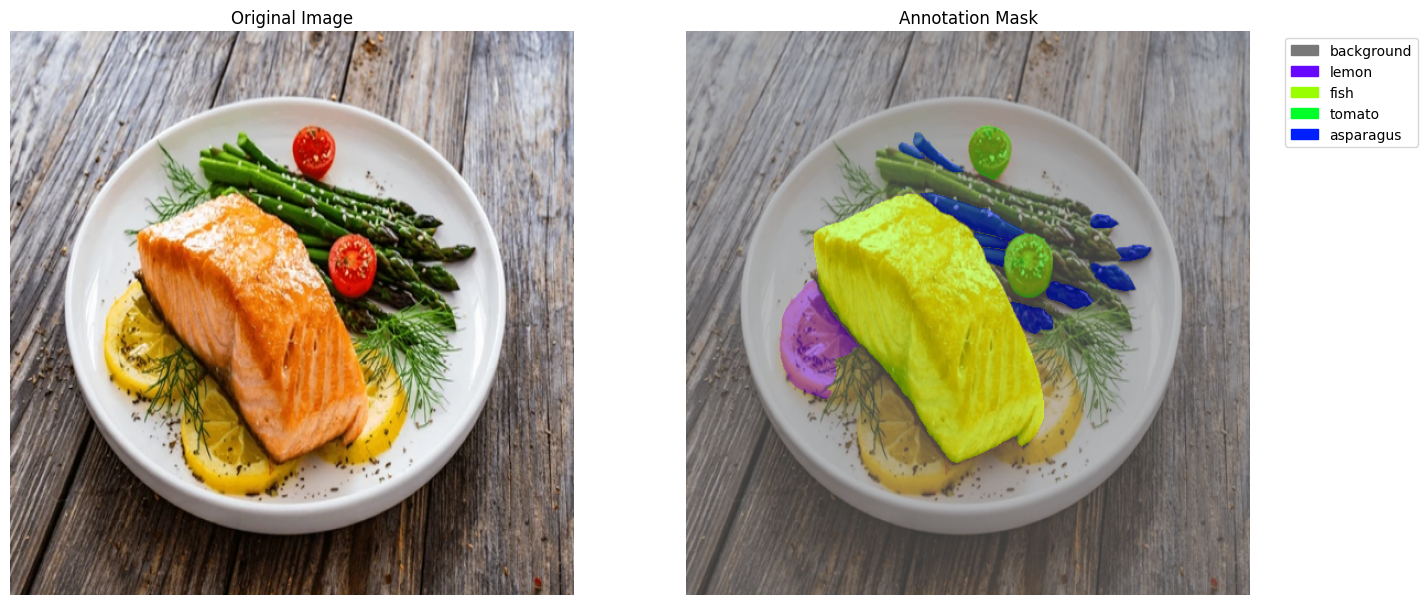

In [5]:
mask = enhanced_model.predict_segmentation_mask(image_test_rgb)
enhanced_model.preview_image_segmentation(image_test_rgb, mask)

In [6]:
np.unique(mask)

array([ 0, 37, 54, 73, 85], dtype=int64)

In [7]:
filtered_mask = np.where(mask == 54, 1, 0).astype(np.uint8)

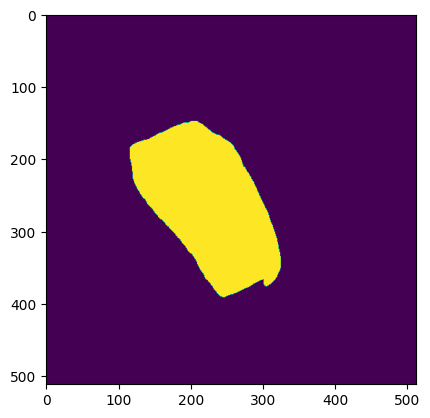

In [8]:
plt.imshow(filtered_mask)

In [9]:
mask_resized_to_original_size = cv2.resize(filtered_mask, (image_test.shape[1], image_test.shape[0]), interpolation=cv2.INTER_NEAREST)
mask_resized_to_original_size = mask_resized_to_original_size.astype(np.uint8)

In [10]:
image_test_rgb = cv2.bitwise_and(image_test, image_test, mask=mask_resized_to_original_size)

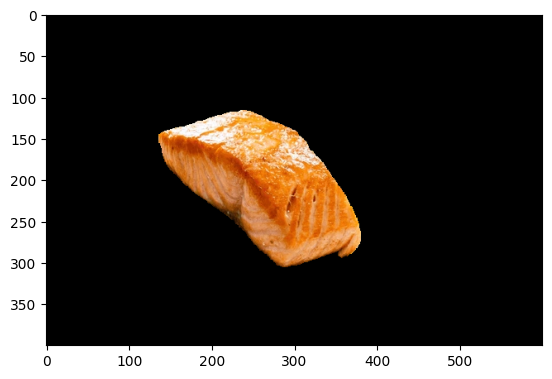

In [11]:
plt.imshow(image_test_rgb)

In [19]:
volume_estimator = VolumeEstimator(depth_layers=18)

In [20]:
volume_estimator.estimate_volume(image_test_rgb)

158095.87